In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

#plt.style.use(['science','no-latex'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [16]:
def compute_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs, errors

def compute_indep_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    print(IGs_vs_alpha.shape)
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs_vs_alpha[:,np.arange(n_eps),alphas_max]

### Rossler, identical

In [17]:
epsilons = np.linspace(0.,0.25,30)
Ls = np.linspace(100,30000,50,dtype=int) # for CCM
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/rossler_id/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/rossler_id/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(epsilons)))
egc_index_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles/rossler_id/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(epsilons),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(epsilons),len(Ls)))
for seed in range(nseeds):
    ccm_X_to_Y[seed], ccm_Y_to_X[seed] = pickle.load(open(f"./ccm/pickles/rossler_id/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(epsilons)))
L_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L/pickles/rossler_id/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)


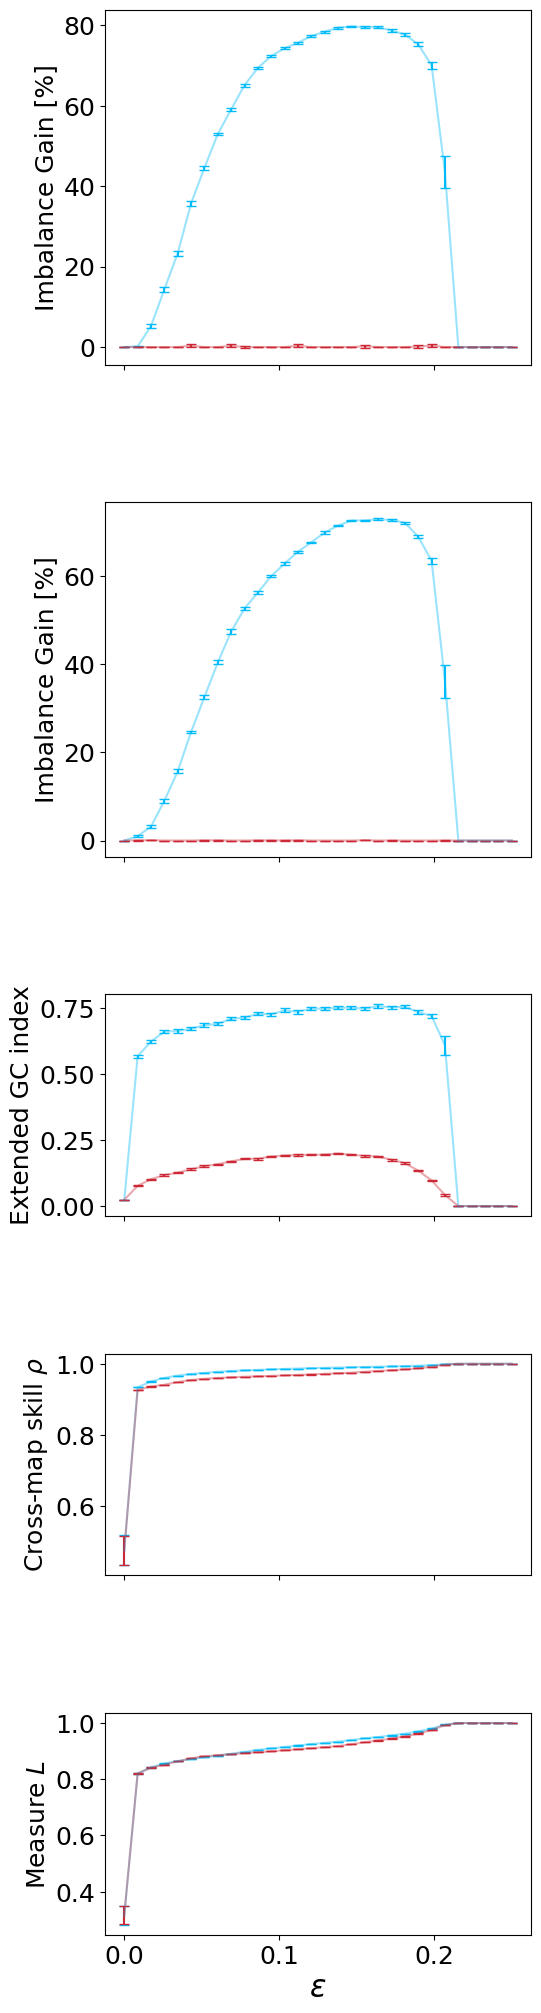

In [18]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(5,1,figsize=(5.5,25), gridspec_kw={'height_ratios': [1.6,1.6,1.0,1.0,1.0],'hspace': 0.5})

ax[0].errorbar(epsilons, IGs_X_to_Y, IGs_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, IGs_Y_to_X, IGs_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, IGs_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Imbalance Gain [%]")
ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, IGs_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
ax[1].set(ylabel="Imbalance Gain [%]")
ax[1].axes.xaxis.set_ticklabels([])

ax[2].errorbar(epsilons, egc_index_X_to_Y_avg, egc_index_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].errorbar(epsilons, egc_index_Y_to_X_avg, egc_index_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].plot(epsilons, egc_index_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[2].plot(epsilons, egc_index_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
ax[2].set(ylabel="Extended GC index")
ax[2].axes.xaxis.set_ticklabels([])

ax[3].errorbar(epsilons, ccm_X_to_Y_avg, ccm_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].errorbar(epsilons, ccm_Y_to_X_avg, ccm_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].plot(epsilons, ccm_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[3].plot(epsilons, ccm_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
ax[3].set(ylabel="Cross-map skill $\\rho$")
ax[3].axes.xaxis.set_ticklabels([])

ax[4].errorbar(epsilons, L_X_to_Y_avg, L_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].errorbar(epsilons, L_Y_to_X_avg, L_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].plot(epsilons, L_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[4].plot(epsilons, L_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
ax[4].set(ylabel="Measure $L$")
ax[4].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig("./figures/rossler_id.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Rossler, different

In [7]:
epsilons = np.linspace(0.,0.25,30)
Ls = np.linspace(100,20000,50,dtype=int) # for CCM
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/rossler_diff/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/rossler_diff/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(epsilons)))
egc_index_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles/rossler_diff/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(epsilons),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(epsilons),len(Ls)))
for seed in range(nseeds):
    ccm_X_to_Y[seed], ccm_Y_to_X[seed] = pickle.load(open(f"./ccm/pickles/rossler_diff/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(epsilons)))
L_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L/pickles/rossler_diff/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)


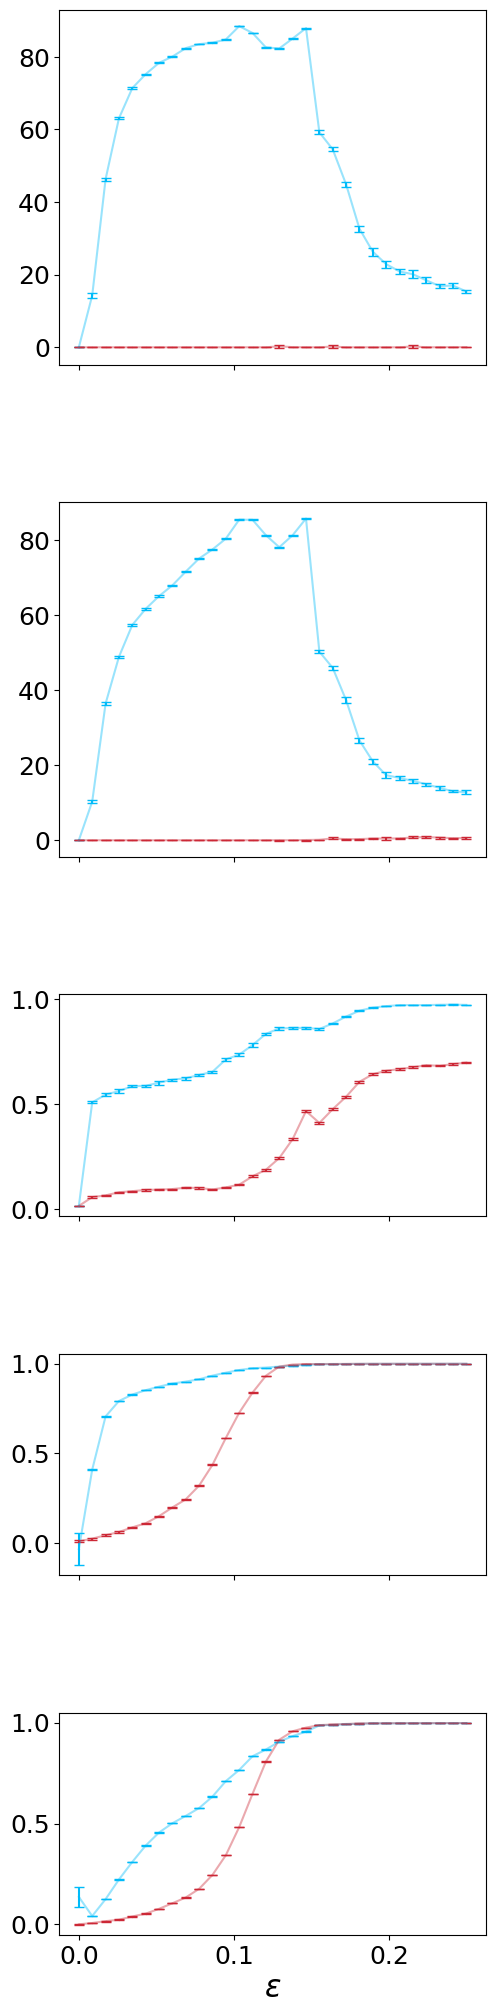

In [8]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(5,1,figsize=(5.5,25), gridspec_kw={'height_ratios': [1.6,1.6,1.0,1.0,1.0],'hspace': 0.5})

ax[0].errorbar(epsilons, IGs_X_to_Y, IGs_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, IGs_Y_to_X, IGs_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, IGs_Y_to_X, '-', color=colors[1], alpha=0.4)
#ax[0].set(ylabel="Imbalance Gain [%]")
ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, IGs_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Imbalance Gain [%]")
ax[1].axes.xaxis.set_ticklabels([])

ax[2].errorbar(epsilons, egc_index_X_to_Y_avg, egc_index_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].errorbar(epsilons, egc_index_Y_to_X_avg, egc_index_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].plot(epsilons, egc_index_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[2].plot(epsilons, egc_index_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[2].set(ylabel="Extended GC index")
ax[2].axes.xaxis.set_ticklabels([])

ax[3].errorbar(epsilons, ccm_X_to_Y_avg, ccm_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].errorbar(epsilons, ccm_Y_to_X_avg, ccm_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].plot(epsilons, ccm_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[3].plot(epsilons, ccm_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[3].set(ylabel="Cross-map skill $\\rho$")
ax[3].axes.xaxis.set_ticklabels([])

ax[4].errorbar(epsilons, L_X_to_Y_avg, L_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].errorbar(epsilons, L_Y_to_X_avg, L_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].plot(epsilons, L_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[4].plot(epsilons, L_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[4].set(ylabel="Measure $L$")
ax[4].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig("./figures/rossler_diff.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Lorenz

In [9]:
epsilons = np.linspace(0.,0.3,31)
Ls = np.linspace(100,40000,50,dtype=int) # for CCM
alphas = np.linspace(0.,0.3,50) # for IG

selected_seeds = np.delete(np.arange(26),[2,4,5,6,15,23])
nseeds = len(selected_seeds)
print(f"Number of independent realizations: {nseeds}")

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for i_seed,seed in enumerate(selected_seeds):#range(nseeds):
    info_imbalances_X_to_Y[i_seed], info_imbalances_Y_to_X[i_seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for i_seed,seed in enumerate(selected_seeds):#range(nseeds):
    info_imbalances_X_to_Y_emb[i_seed], info_imbalances_Y_to_X_emb[i_seed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(epsilons)))
egc_index_Y_to_X = np.zeros((nseeds,len(epsilons)))
for i_seed,seed in enumerate(selected_seeds):#range(nseeds):
    egc_index_X_to_Y[i_seed], egc_index_Y_to_X[i_seed] = pickle.load(open(f"./extended_gc/pickles/lorenz/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(epsilons),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(epsilons),len(Ls)))
for i_seed,seed in enumerate(selected_seeds):#range(nseeds):
    ccm_X_to_Y[i_seed], ccm_Y_to_X[i_seed] = pickle.load(open(f"./ccm/pickles/lorenz/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(epsilons)))
L_Y_to_X = np.zeros((nseeds,len(epsilons)))
for i_seed,seed in enumerate(selected_seeds):#range(nseeds):
    L_X_to_Y[i_seed], L_Y_to_X[i_seed] = pickle.load(open(f"./measure_L/pickles/lorenz/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)


Number of independent realizations: 20


(20, 31, 50)
(20, 31, 50)
(20, 31, 50)
(20, 31, 50)


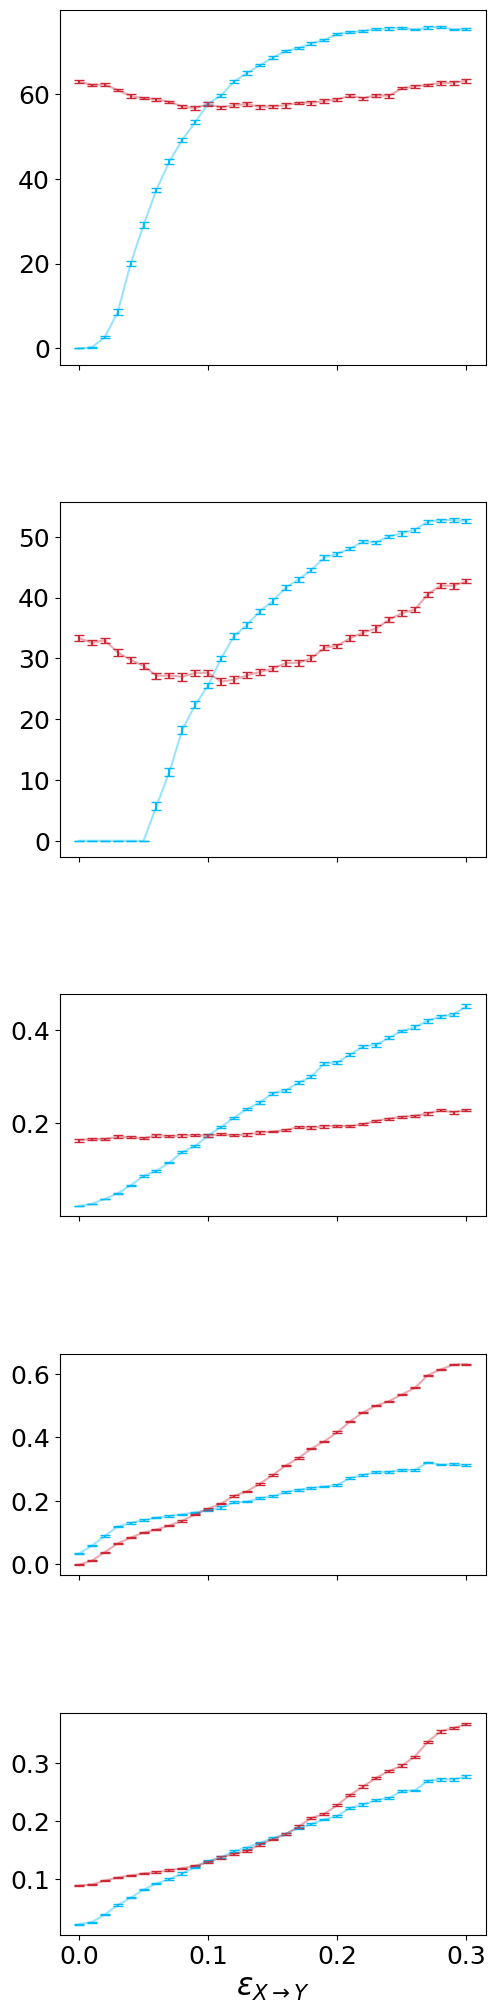

In [10]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(5,1,figsize=(5.5,25), gridspec_kw={'height_ratios': [1.6,1.6,1.0,1.0,1.0],'hspace': 0.5})

ax[0].errorbar(epsilons, IGs_X_to_Y, IGs_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, IGs_Y_to_X, IGs_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, IGs_Y_to_X, '-', color=colors[1], alpha=0.4)
#ax[0].set(ylabel="Imbalance Gain [%]")
ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, IGs_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Imbalance Gain [%]")
ax[1].axes.xaxis.set_ticklabels([])

ax[2].errorbar(epsilons, egc_index_X_to_Y_avg, egc_index_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].errorbar(epsilons, egc_index_Y_to_X_avg, egc_index_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].plot(epsilons, egc_index_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[2].plot(epsilons, egc_index_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[2].set(ylabel="Extended GC index")
ax[2].axes.xaxis.set_ticklabels([])

ax[3].errorbar(epsilons, ccm_X_to_Y_avg, ccm_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].errorbar(epsilons, ccm_Y_to_X_avg, ccm_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].plot(epsilons, ccm_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[3].plot(epsilons, ccm_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[3].set(ylabel="Cross-map skill $\\rho$")
ax[3].axes.xaxis.set_ticklabels([])

ax[4].errorbar(epsilons, L_X_to_Y_avg, L_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].errorbar(epsilons, L_Y_to_X_avg, L_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].plot(epsilons, L_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[4].plot(epsilons, L_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[4].set(ylabel="Measure $L$")
ax[4].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=22)

plt.savefig("./figures/lorenz.pdf", dpi=300, bbox_inches='tight')
plt.show()

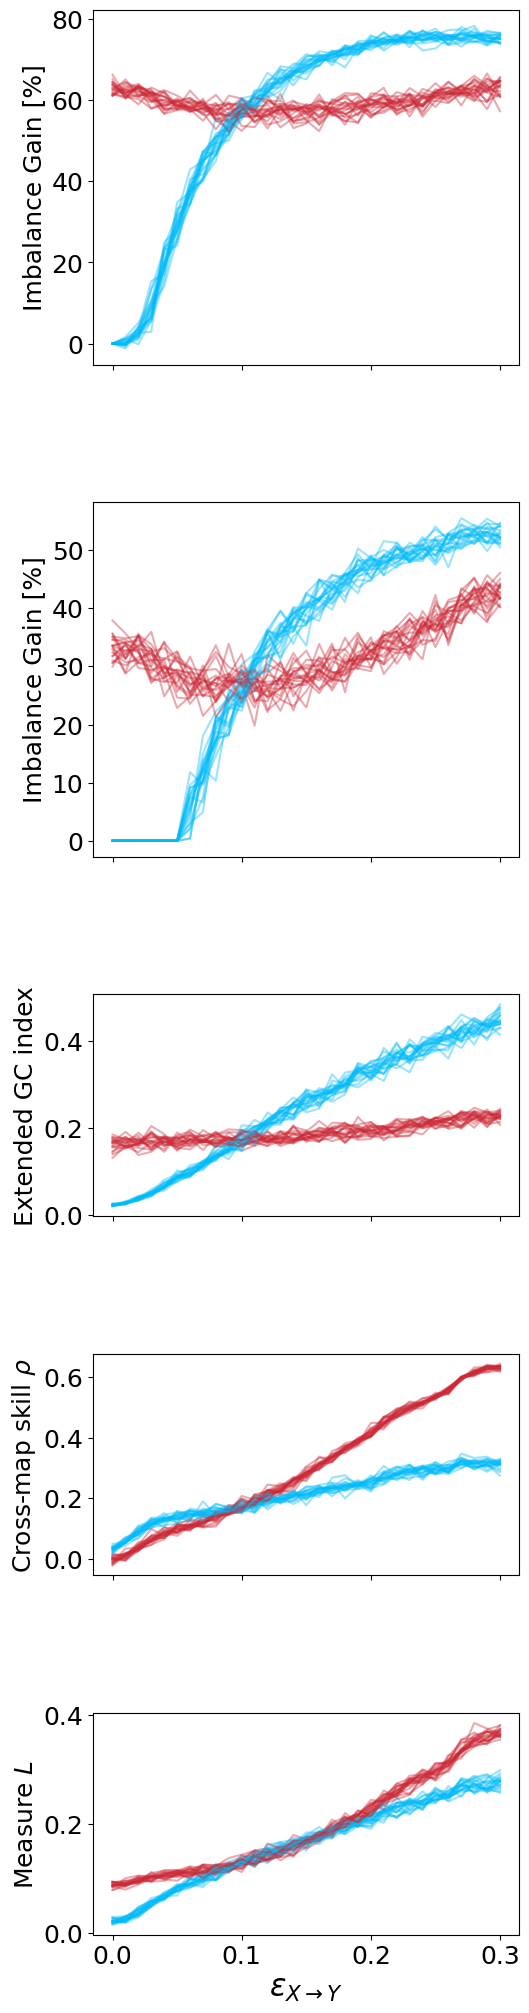

In [11]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(5,1,figsize=(5.5,25), gridspec_kw={'height_ratios': [1.6,1.6,1.0,1.0,1.0],'hspace': 0.5})

#ax[0].plot(epsilons, IGs_X_to_Y, markers[0], color=colors[0], label="$X\\rightarrow Y$")
#ax[0].plot(epsilons, IGs_Y_to_X, markers[1], color=colors[1], label="$Y\\rightarrow X$")
for i_seed, seed in enumerate(selected_seeds):
    ax[0].plot(epsilons, IGs_X_to_Y_indep[i_seed], color=colors[0], alpha=0.4)
    ax[0].plot(epsilons, IGs_Y_to_X_indep[i_seed], color=colors[1], alpha=0.4)
ax[0].set(ylabel="Imbalance Gain [%]")
ax[0].axes.xaxis.set_ticklabels([])

#ax[1].plot(epsilons, IGs_X_to_Y_emb, markers[0], color=colors[0], label="$X\\rightarrow Y$")
#ax[1].plot(epsilons, IGs_Y_to_X_emb, markers[1], color=colors[1], label="$Y\\rightarrow X$")
for i_seed, seed in enumerate(selected_seeds):
    ax[1].plot(epsilons, IGs_X_to_Y_emb_indep[i_seed], color=colors[0], alpha=0.4)
    ax[1].plot(epsilons, IGs_Y_to_X_emb_indep[i_seed], color=colors[1], alpha=0.4)
ax[1].set(ylabel="Imbalance Gain [%]")
ax[1].axes.xaxis.set_ticklabels([])

#ax[2].plot(epsilons, egc_index_X_to_Y_avg, markers[0], color=colors[0], label="$X\\rightarrow Y$")
#ax[2].plot(epsilons, egc_index_Y_to_X_avg, markers[1], color=colors[1], label="$Y\\rightarrow X$")
for i_seed, seed in enumerate(selected_seeds):
    ax[2].plot(epsilons, egc_index_X_to_Y[i_seed], color=colors[0], alpha=0.4)
    ax[2].plot(epsilons, egc_index_Y_to_X[i_seed], color=colors[1], alpha=0.4)
ax[2].set(ylabel="Extended GC index")
ax[2].axes.xaxis.set_ticklabels([])

#ax[3].plot(epsilons, ccm_X_to_Y_avg, markers[0], color=colors[0], label="$X\\rightarrow Y$")
#ax[3].plot(epsilons, ccm_Y_to_X_avg, markers[1], color=colors[1], label="$Y\\rightarrow X$")
for i_seed, seed in enumerate(selected_seeds):
    ax[3].plot(epsilons, ccm_X_to_Y[i_seed,:,-1], color=colors[0], alpha=0.4)
    ax[3].plot(epsilons, ccm_Y_to_X[i_seed,:,-1], color=colors[1], alpha=0.4)
ax[3].set(ylabel="Cross-map skill $\\rho$")
ax[3].axes.xaxis.set_ticklabels([])

#ax[4].plot(epsilons, L_X_to_Y_avg, markers[0], color=colors[0], label="$X\\rightarrow Y$")
#ax[4].plot(epsilons, L_Y_to_X_avg, markers[1], color=colors[1], label="$Y\\rightarrow X$")
for i_seed, seed in enumerate(selected_seeds):
    ax[4].plot(epsilons, L_X_to_Y[i_seed], color=colors[0], alpha=0.4)
    ax[4].plot(epsilons, L_Y_to_X[i_seed], color=colors[1], alpha=0.4)
ax[4].set(ylabel="Measure $L$")
ax[4].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=22)

plt.show()

### Lorenz 96

In [12]:
epsilons = np.linspace(0.,1.5,31)
Ls = np.linspace(100,50000,50,dtype=int) # for CCM
alphas = np.linspace(0.,1.5,50) # for IG
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz96/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz96/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(epsilons)))
egc_index_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles/lorenz96/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(epsilons),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(epsilons),len(Ls)))
for seed in range(nseeds):
    ccm_X_to_Y[seed], ccm_Y_to_X[seed] = pickle.load(open(f"./ccm/pickles/lorenz96/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(epsilons)))
L_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L/pickles/lorenz96/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)


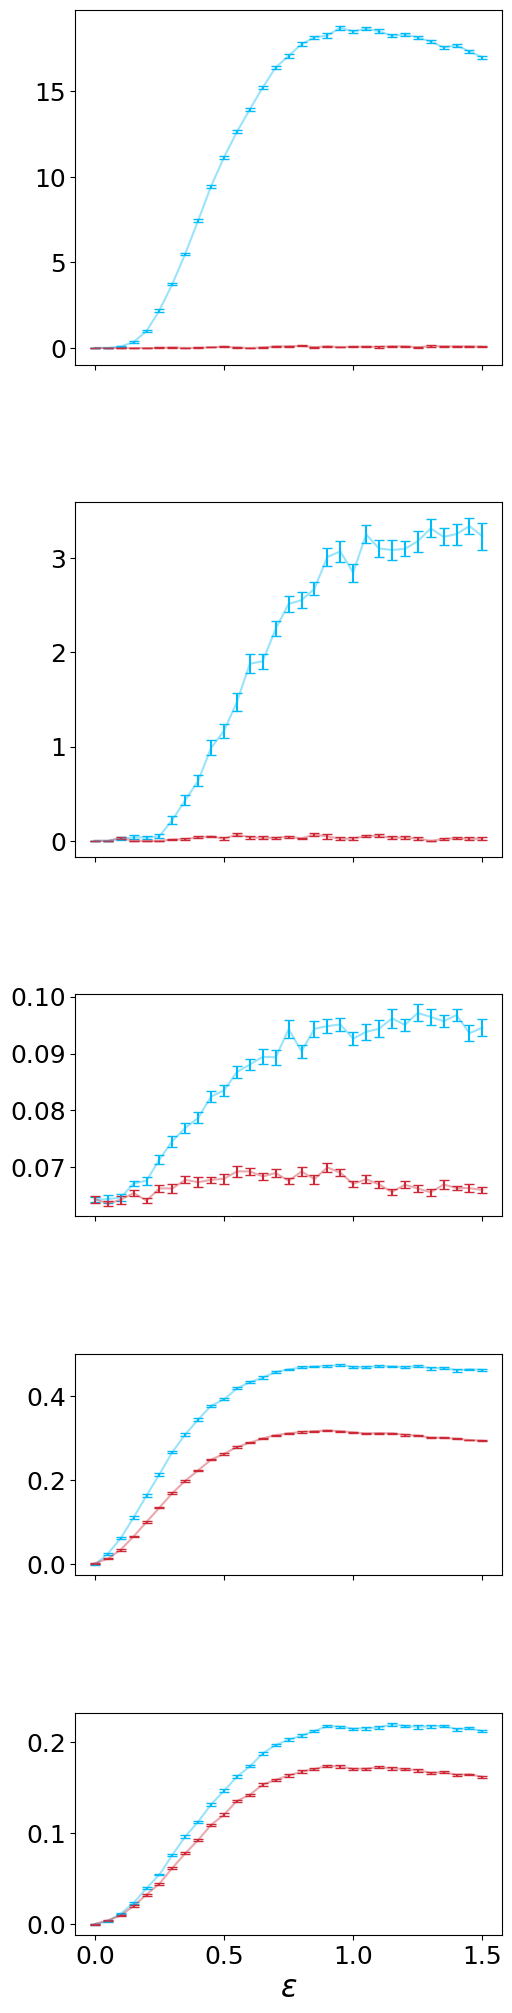

In [15]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(5,1,figsize=(5.5,25), gridspec_kw={'height_ratios': [1.6,1.6,1.0,1.0,1.0],'hspace': 0.5})

ax[0].errorbar(epsilons, IGs_X_to_Y, IGs_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1, label="$X\\rightarrow Y$")
ax[0].errorbar(epsilons, IGs_Y_to_X, IGs_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1, label="$Y\\rightarrow X$")
ax[0].plot(epsilons, IGs_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, IGs_Y_to_X, '-', color=colors[1], alpha=0.4)
#ax[0].set(ylabel="Imbalance Gain [%]")
ax[0].axes.xaxis.set_ticklabels([])
#ax[0].legend(loc="center right")

ax[1].errorbar(epsilons, IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, IGs_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Imbalance Gain [%]")
ax[1].axes.xaxis.set_ticklabels([])

ax[2].errorbar(epsilons, egc_index_X_to_Y_avg, egc_index_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].errorbar(epsilons, egc_index_Y_to_X_avg, egc_index_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].plot(epsilons, egc_index_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[2].plot(epsilons, egc_index_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[2].set(ylabel="Extended GC index")
ax[2].axes.xaxis.set_ticklabels([])

ax[3].errorbar(epsilons, ccm_X_to_Y_avg, ccm_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].errorbar(epsilons, ccm_Y_to_X_avg, ccm_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].plot(epsilons, ccm_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[3].plot(epsilons, ccm_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[3].set(ylabel="Cross-map skill $\\rho$")
ax[3].axes.xaxis.set_ticklabels([])

ax[4].errorbar(epsilons, L_X_to_Y_avg, L_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].errorbar(epsilons, L_Y_to_X_avg, L_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].plot(epsilons, L_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[4].plot(epsilons, L_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[4].set(ylabel="Measure $L$")
ax[4].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig("./figures/lorenz96_nolegend.pdf", dpi=300, bbox_inches='tight')
plt.show()